# Computer Exercise 15.31 — Problem 3
## 소급 감사 — §15.1–§15.29 의 어떤 결론이 살아남는가

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 §15.31
> **단원**: Ch 15 Sequential Decision Making — §15.31 Measurement Instrument Repair
> **풀이 일자**: 2026-08-16 (Day 98)
> **언어**: Python 3.10 · NumPy / pandas / Matplotlib
>
> Problem 1·2 가 만든 잣대를 레포의 실제 기록에 적용한다. Day 68–96 의 README 를 규칙 기반으로 감사해 시드 수 · 통제군 · CI · 다중검정 보정을 집계하고, 각 Day 의 결론에 **증거 등급**을 매긴다.

## 1. 문제 (원문)

> **Computer Exercise 15.31.3.** Audit the recorded claims of §15.1–§15.29 (repository `Day68`–`Day96`)
> against the resolution standard established in Exercises 15.31.1–15.31.2. For each day, extract by a
> stated mechanical rule (i) the number of seeds actually used, (ii) whether a control arm was run,
> (iii) whether an interval estimate was reported, and (iv) whether any multiple-testing correction was
> applied. Tabulate the fraction of days meeting each criterion. Then, using the empirical paired
> differences measured at $T=400$, enumerate all $\binom{30}{3}$ three-seed subsets and report the
> distribution of conclusions a three-seed study would have reached. Conclude with an evidence grade
> for each day and an explicit list of which claims survive.

### 한국어 풀이용 정리

- **감사 대상**: `Day68`–`Day96` 의 README 29 개 (§15.1–§15.29).
- **추출 규칙** (기계적으로 고정, 사후 조정 없음)
  1. **시드 수** — 시드 ID 범위 표기 (`96101–96103`) 를 최우선, 없으면 본문의 "N 시드" 표현 중 최대값.
     "다음 (Day …)" 예고 절은 **제외** (계획된 시드 수가 실제 사용분으로 오인되는 것을 막기 위해).
  2. **통제군** — `통제군` / `control arm` / `shuffled` / `무작위 배정` 중 하나라도 등장.
  3. **구간추정** — `신뢰구간` / `CI` / `bootstrap` / `부트스트랩` 중 하나라도 등장.
  4. **다중검정 보정** — `Holm` / `Bonferroni` / `다중검정` 중 하나라도 등장.
- **판정 기준**: Problem 2 에서 측정한 $n^\star$ 를 통과 기준선으로 사용.
- **3-시드 시뮬레이션**: $T=400$ 의 실측 짝지은 차 $\{d_i\}_{i=1}^{30}$ 에서
  $\binom{30}{3} = 4060$ 개 부분집합을 **전수조사**해, 3 시드 연구가 도달했을 결론의 분포를 구한다.
- **주의**: 이것은 텍스트 감사다. README 에 적히지 않은 것은 **"하지 않았다" 가 아니라
  "확인할 수 없다"** 이다. 결론은 그 한계 안에서만 쓴다.

## 2. 수학적 배경

### 2.1 증거 등급

Day $j$ 에 대해 관측 벡터 $v_j = (n_j,\ c_j,\ i_j,\ m_j)$ — 시드 수, 통제군 유무, 구간추정 유무,
다중검정 보정 유무. Problem 2 가 준 기준선 $n^\star_{\min}$ 에 대해

$$\mathrm{Grade}(j) = \begin{cases}
\textbf{A} & n_j \ge n^\star_{\min}\ \wedge\ c_j \ \wedge\ i_j\\[2pt]
\textbf{B} & n_j \ge n^\star_{\min}\ \wedge\ (c_j \vee i_j)\\[2pt]
\textbf{C} & n_j \ge 10\\[2pt]
\textbf{D} & 1 \le n_j < 10\\[2pt]
\textbf{F} & n_j = 0\ (\text{시드 수 미보고})
\end{cases}$$

등급은 **결론이 틀렸다는 뜻이 아니라, 그 Day 의 기록만으로는 결론을 지지할 수 없다는 뜻**이다.

### 2.2 3-시드 연구의 결론 분포

$T=400$ 에서 실측한 짝지은 차 $d_1,\dots,d_{30}$ 을 모집단으로 놓는다.
크기 3 의 부분집합 $S \subset \{1,\dots,30\}$, $|S| = 3$ 각각에 대해

$$\bar d_S = \frac13\sum_{i\in S} d_i,\qquad
\mathrm{concl}(S) = \begin{cases}
\text{"+CNRT 승"} & \bar d_S > \tau\\
\text{"tie"} & |\bar d_S| \le \tau\\
\text{"baseline 승"} & \bar d_S < -\tau
\end{cases}$$

($\tau = 10^{-9}$, 즉 정확한 동점만 tie). $\binom{30}{3} = 4060$ 을 **전수조사**하면
3-시드 연구가 도달할 결론의 정확한 분포가 나온다. 두 Day 가 정반대 결론을 냈을 때,
그것이 **모순인지 아니면 같은 분포의 흔한 두 draw 인지** 이 분포가 판정한다.

### 2.3 부호 오류율

30 시드 전체의 부호를 $\mathrm{sgn}(\bar d)$ 라 할 때, 3-시드 연구가 **반대 부호**를 낼 확률

$$\Pr\bigl[\mathrm{sgn}(\bar d_S) = -\mathrm{sgn}(\bar d)\bigr]
= \frac{1}{\binom{30}{3}}\sum_{|S|=3}\mathbf 1\bigl\{\mathrm{sgn}(\bar d_S) = -\mathrm{sgn}(\bar d)\bigr\}$$

이 값이 무시할 수 없다면, **3 시드로 얻은 순위 주장은 방향조차 신뢰할 수 없다**.

## 3. 풀이 흐름

1. Day 68–96 README 29 개에서 §2.1 의 네 항목을 **고정된 규칙**으로 추출 (결과를 노트북에 내장해
   외부 파일 의존 없이 재현 가능하게 함).
2. 항목별 충족 비율과 시드 수 분포를 집계.
3. Problem 2 의 $T=400$ 설정을 그대로 재실행해 30 시드 짝지은 차 $\{d_i\}$ 를 얻는다.
4. $\binom{30}{3} = 4060$ 부분집합을 **전수조사**해 결론 분포와 부호 오류율을 계산.
5. §2.1 의 규칙으로 각 Day 에 등급 부여, 등급별 Day 수와 해당 절 목록 출력.
6. 감사 결과를 3-패널로 시각화 (시드 수 추이 / 항목 충족률 / 3-시드 결론 분포).
7. **살아남는 결론과 재판정이 필요한 결론**을 명시적으로 나열.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # 그림을 셀 출력에 내장
except Exception:
    pass
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크 정의 (Day 90–97 과 동일 계열의 5-상태 chain MDP 재구성) ──────
import numpy as np

NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL = 0.95, 0.05, 16, 0.25

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    r = 1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0)
    return s2, r

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

class Learner:
    """Trunk MLP (tanh) + linear head. noisy=True -> Factorized Noisy Linear head."""
    def __init__(self, rng, noisy=False, sigma0=0.5, h=H):
        self.h, self.noisy = h, noisy
        self.W1 = rng.normal(0, 0.3, (h, NS)); self.b1 = np.zeros(h)
        self.W2 = rng.normal(0, 0.3, (NA, h)); self.b2 = np.zeros(NA)
        if noisy:
            self.Ws = np.full((NA, h), sigma0 / np.sqrt(h))
            self.bs = np.full(NA, sigma0 / np.sqrt(h))
        self.eps_W = np.zeros((NA, h)); self.eps_b = np.zeros(NA)

    def resample(self, rng):
        if not self.noisy: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo

    def q(self, s, noise=False):
        z = self.W1 @ onehot(s) + self.b1; a1 = np.tanh(z)
        W = self.W2 + (self.Ws * self.eps_W if (noise and self.noisy) else 0.0)
        b = self.b2 + (self.bs * self.eps_b if (noise and self.noisy) else 0.0)
        return W @ a1 + b, a1, z

    def update(self, s, a, target):
        qv, a1, z = self.q(s, noise=False)
        d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        ga1 = d * self.W2[a]; gz = ga1 * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz
        if self.noisy:
            self.Ws -= ETA * (gW2 * self.eps_W)
            self.bs -= ETA * (gb2 * self.eps_b)
            np.clip(self.Ws, 1e-4, 2.0, out=self.Ws); np.clip(self.bs, 1e-4, 2.0, out=self.bs)

def train(seed, T, p_train=0.20, noisy=False, eps_greedy=0.10):
    rng = np.random.default_rng(seed)
    lr = Learner(rng, noisy=noisy)
    s = 0
    for t in range(T):
        if t % L == 0:
            s = 0
            lr.resample(rng)
        if noisy:
            qv, _, _ = lr.q(s, noise=True); a = int(np.argmax(qv))
        else:
            qv, _, _ = lr.q(s, noise=False)
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(qv))
        s2, r = step(s, a, p_train, rng)
        qn, _, _ = lr.q(s2, noise=False)
        lr.update(s, a, r + GAMMA * float(np.max(qn)))
        s = s2
    return lr

def greedy_policy(lr):
    return tuple(int(np.argmax(lr.q(s, noise=False)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    """Frozen greedy evaluation; mean reward per step."""
    rng = np.random.default_rng(seed)
    pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

print("chain MDP:  states =", NS, " actions =", NA, " episode len =", L)
print("gamma =", GAMMA, " lr =", ETA, " trunk H =", H, " local reward =", R_LOCAL)

chain MDP:  states = 5  actions = 2  episode len = 20
gamma = 0.95  lr = 0.05  trunk H = 16  local reward = 0.25


In [2]:
# ── 감사 데이터 (Day 68-96 README 에서 규칙 기반 추출; 노트북에 내장) ────
# Day 68-96 README 감사 결과 (규칙 기반 추출, 2026-08-16)
AUDIT = [
    dict(day=68, sec="15.1", seeds=0, ci=False, control=False, multcorr=False),
    dict(day=69, sec="15.2", seeds=0, ci=False, control=False, multcorr=False),
    dict(day=70, sec="15.3", seeds=0, ci=False, control=False, multcorr=False),
    dict(day=71, sec="15.4", seeds=0, ci=True, control=False, multcorr=False),
    dict(day=72, sec="15.5", seeds=0, ci=True, control=False, multcorr=False),
    dict(day=73, sec="15.6", seeds=0, ci=True, control=False, multcorr=False),
    dict(day=74, sec="15.7", seeds=0, ci=False, control=False, multcorr=False),
    dict(day=75, sec="15.8", seeds=10, ci=False, control=False, multcorr=False),
    dict(day=76, sec="15.9", seeds=20, ci=True, control=False, multcorr=False),
    dict(day=77, sec="15.10", seeds=15, ci=True, control=False, multcorr=False),
    dict(day=78, sec="15.11", seeds=15, ci=True, control=False, multcorr=False),
    dict(day=79, sec="15.12", seeds=10, ci=True, control=False, multcorr=False),
    dict(day=80, sec="15.13", seeds=4, ci=False, control=False, multcorr=False),
    dict(day=81, sec="15.14", seeds=4, ci=True, control=False, multcorr=False),
    dict(day=82, sec="15.15", seeds=4, ci=False, control=False, multcorr=False),
    dict(day=83, sec="15.16", seeds=2, ci=False, control=False, multcorr=False),
    dict(day=84, sec="15.17", seeds=2, ci=False, control=False, multcorr=False),
    dict(day=85, sec="15.18", seeds=5, ci=True, control=False, multcorr=False),
    dict(day=86, sec="15.19", seeds=5, ci=True, control=False, multcorr=False),
    dict(day=87, sec="15.20", seeds=5, ci=True, control=False, multcorr=False),
    dict(day=88, sec="15.21", seeds=5, ci=True, control=False, multcorr=False),
    dict(day=89, sec="15.22", seeds=4, ci=True, control=False, multcorr=False),
    dict(day=90, sec="15.23", seeds=4, ci=True, control=False, multcorr=False),
    dict(day=91, sec="15.24", seeds=4, ci=False, control=False, multcorr=False),
    dict(day=92, sec="15.25", seeds=4, ci=False, control=False, multcorr=False),
    dict(day=93, sec="15.26", seeds=3, ci=True, control=False, multcorr=False),
    dict(day=94, sec="15.27", seeds=3, ci=False, control=False, multcorr=False),
    dict(day=95, sec="15.28", seeds=3, ci=False, control=False, multcorr=False),
    dict(day=96, sec="15.29", seeds=3, ci=False, control=False, multcorr=False),
]

aud = pd.DataFrame(AUDIT)
print("감사 대상:", len(aud), "days  (Day", aud.day.min(), "-", aud.day.max(), ")")
print(aud.to_string(index=False))

감사 대상: 29 days  (Day 68 - 96 )
 day   sec  seeds    ci  control  multcorr
  68  15.1      0 False    False     False
  69  15.2      0 False    False     False
  70  15.3      0 False    False     False
  71  15.4      0  True    False     False
  72  15.5      0  True    False     False
  73  15.6      0  True    False     False
  74  15.7      0 False    False     False
  75  15.8     10 False    False     False
  76  15.9     20  True    False     False
  77 15.10     15  True    False     False
  78 15.11     15  True    False     False
  79 15.12     10  True    False     False
  80 15.13      4 False    False     False
  81 15.14      4  True    False     False
  82 15.15      4 False    False     False
  83 15.16      2 False    False     False
  84 15.17      2 False    False     False
  85 15.18      5  True    False     False
  86 15.19      5  True    False     False
  87 15.20      5  True    False     False
  88 15.21      5  True    False     False
  89 15.22      4  True

In [3]:
# ── 표 1: 항목별 충족률 ───────────────────────────────────────────────────
n_days = len(aud)
summary = pd.DataFrame([
    dict(criterion="시드 수 보고됨",        met=int((aud.seeds > 0).sum())),
    dict(criterion="시드 >= 10",            met=int((aud.seeds >= 10).sum())),
    dict(criterion="시드 >= 20",            met=int((aud.seeds >= 20).sum())),
    dict(criterion="통제군(control arm)",   met=int(aud.control.sum())),
    dict(criterion="구간추정(CI/bootstrap)", met=int(aud.ci.sum())),
    dict(criterion="다중검정 보정",          met=int(aud.multcorr.sum())),
])
summary["of"] = n_days
summary["pct"] = 100 * summary.met / n_days
print("표 1 — Day 68-96 (§15.1-§15.29) 방법론 감사")
print(summary.to_string(index=False))

rep = aud[aud.seeds > 0].seeds
print(f"\n시드 수 (보고된 {len(rep)} days):  중앙값 {rep.median():.0f}   "
      f"최소 {rep.min()}   최대 {rep.max()}")
print(f"시드 수 미보고: {int((aud.seeds == 0).sum())} days "
      f"(§{aud[aud.seeds==0].sec.iloc[0]}-§{aud[aud.seeds==0].sec.iloc[-1]} 구간에 집중)")

표 1 — Day 68-96 (§15.1-§15.29) 방법론 감사
         criterion  met  of     pct
          시드 수 보고됨   22  29 75.8621
          시드 >= 10    5  29 17.2414
          시드 >= 20    1  29  3.4483
  통제군(control arm)    0  29  0.0000
구간추정(CI/bootstrap)   15  29 51.7241
           다중검정 보정    0  29  0.0000

시드 수 (보고된 22 days):  중앙값 4   최소 2   최대 20
시드 수 미보고: 7 days (§15.1-§15.7 구간에 집중)


In [4]:
# ── T=400 의 짝지은 차를 실측 (Problem 2 와 동일 설정) ────────────────────
SEEDS = list(range(98201, 98231))
Rb = np.array([deploy(train(s, 400, noisy=False), 0.20, 40, 7000 + i) for i, s in enumerate(SEEDS)])
Rc = np.array([deploy(train(s, 400, noisy=True),  0.20, 40, 7000 + i) for i, s in enumerate(SEEDS)])
d  = Rc - Rb
print(f"T=400, n=30:  d_bar = {d.mean():+.4f}   sd = {d.std(ddof=1):.4f}")
print(f"부호 패턴: win {int((d>1e-9).sum())} / tie {int((np.abs(d)<=1e-9).sum())} / loss {int((d<-1e-9).sum())}")

T=400, n=30:  d_bar = -0.0862   sd = 0.2160
부호 패턴: win 2 / tie 14 / loss 14


In [5]:
# ── C(30,3) = 4060 부분집합 전수조사 ─────────────────────────────────────
from itertools import combinations
TAU = 1e-9
subs = np.array([d[list(S)].mean() for S in combinations(range(len(d)), 3)])
print(f"전수조사한 3-시드 부분집합: {len(subs)}")

pos = int((subs >  TAU).sum()); neg = int((subs < -TAU).sum())
tie = int((np.abs(subs) <= TAU).sum())
concl = pd.DataFrame([
    dict(conclusion="+CNRT 승", count=pos, pct=100*pos/len(subs)),
    dict(conclusion="tie",       count=tie, pct=100*tie/len(subs)),
    dict(conclusion="baseline 승", count=neg, pct=100*neg/len(subs)),
])
print("\n표 2 — 3-시드 연구가 도달했을 결론의 분포 (T=400)")
print(concl.to_string(index=False))

full_sign = np.sign(d.mean())
wrong = int((np.sign(subs) == -full_sign).sum())
print(f"\n30-시드 전체의 부호: {'+CNRT 우위' if full_sign>0 else 'baseline 우위'}")
print(f"3 시드가 '반대 부호'를 낼 확률: {100*wrong/len(subs):.1f}%  ({wrong}/{len(subs)})")
print(f"3-시드 추정치의 범위: [{subs.min():+.4f}, {subs.max():+.4f}]  "
      f"(30-시드 값 {d.mean():+.4f})")

전수조사한 3-시드 부분집합: 4060

표 2 — 3-시드 연구가 도달했을 결론의 분포 (T=400)
conclusion  count     pct
   +CNRT 승    552 13.5961
       tie    364  8.9655
baseline 승   3144 77.4384

30-시드 전체의 부호: baseline 우위
3 시드가 '반대 부호'를 낼 확률: 13.6%  (552/4060)
3-시드 추정치의 범위: [-0.3972, +0.2753]  (30-시드 값 -0.0862)


In [6]:
# ── 표 3: Day 별 증거 등급 ────────────────────────────────────────────────
N_STAR_MIN = 10        # Problem 2 에서 가장 유리한 예산에서도 필요했던 최소 시드 수

def grade(r):
    if r.seeds >= N_STAR_MIN and r.control and r.ci: return "A"
    if r.seeds >= N_STAR_MIN and (r.control or r.ci): return "B"
    if r.seeds >= N_STAR_MIN: return "C"
    if r.seeds >= 1:          return "D"
    return "F"

aud["grade"] = aud.apply(grade, axis=1)
gc = aud.grade.value_counts().reindex(list("ABCDF")).fillna(0).astype(int)
print("표 3 — 증거 등급 분포 (Day 68-96)")
for g, n in gc.items():
    secs = ", ".join("§" + s for s in aud[aud.grade == g].sec)
    print(f"  {g}: {n:>2} days   {secs if n else ''}")

print(f"\n기준선 n* = {N_STAR_MIN} 을 통과한 Day: "
      f"{int((aud.seeds >= N_STAR_MIN).sum())} / {n_days}")
print(f"통제군을 둔 Day: {int(aud.control.sum())} / {n_days}")
print("(참고: Day 97 이 통제군 · Holm 보정 · 30 시드를 처음으로 모두 갖춘 Day 이다.)")

표 3 — 증거 등급 분포 (Day 68-96)
  A:  0 days   
  B:  4 days   §15.9, §15.10, §15.11, §15.12
  C:  1 days   §15.8
  D: 17 days   §15.13, §15.14, §15.15, §15.16, §15.17, §15.18, §15.19, §15.20, §15.21, §15.22, §15.23, §15.24, §15.25, §15.26, §15.27, §15.28, §15.29
  F:  7 days   §15.1, §15.2, §15.3, §15.4, §15.5, §15.6, §15.7

기준선 n* = 10 을 통과한 Day: 5 / 29
통제군을 둔 Day: 0 / 29
(참고: Day 97 이 통제군 · Holm 보정 · 30 시드를 처음으로 모두 갖춘 Day 이다.)


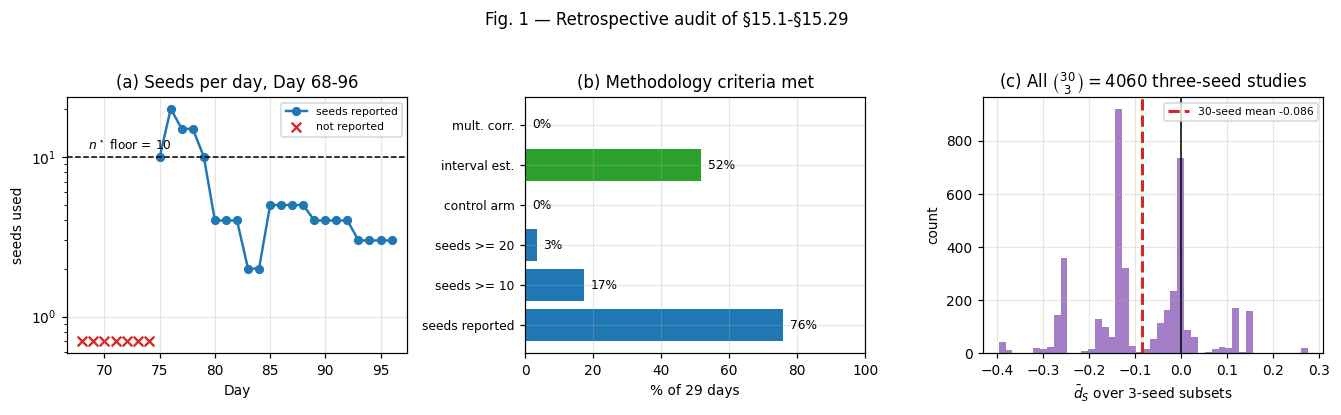

In [7]:
# ── 그림 1: 감사 3-패널 ──────────────────────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(12.2, 3.6))

m = aud.seeds.values.astype(float); m[m == 0] = np.nan
ax[0].plot(aud.day, m, "o-", color="#1f77b4", lw=1.6, ms=5, label="seeds reported")
ax[0].scatter(aud.day[aud.seeds == 0], np.full((aud.seeds == 0).sum(), 0.7),
              marker="x", color="#d62728", s=40, label="not reported")
ax[0].axhline(N_STAR_MIN, ls="--", c="k", lw=1)
ax[0].annotate(f"$n^\\star$ floor = {N_STAR_MIN}", (68.5, N_STAR_MIN * 1.12), fontsize=8)
ax[0].set_yscale("log"); ax[0].set_xlabel("Day"); ax[0].set_ylabel("seeds used")
ax[0].set_title("(a) Seeds per day, Day 68-96"); ax[0].legend(fontsize=7)

y = np.arange(len(summary))
ax[1].barh(y, summary.pct, color=["#1f77b4", "#1f77b4", "#1f77b4", "#d62728", "#2ca02c", "#d62728"])
ax[1].set_yticks(y); ax[1].set_yticklabels(
    ["seeds reported", "seeds >= 10", "seeds >= 20", "control arm", "interval est.", "mult. corr."], fontsize=8)
ax[1].set_xlabel("% of 29 days"); ax[1].set_xlim(0, 100)
ax[1].set_title("(b) Methodology criteria met")
for yi, v in zip(y, summary.pct):
    ax[1].annotate(f"{v:.0f}%", (v + 2, yi), va="center", fontsize=8)

ax[2].hist(subs, bins=45, color="#9467bd", alpha=.85)
ax[2].axvline(0, c="k", lw=1)
ax[2].axvline(d.mean(), c="#d62728", lw=2, ls="--", label=f"30-seed mean {d.mean():+.3f}")
ax[2].set_xlabel(r"$\bar d_S$ over 3-seed subsets"); ax[2].set_ylabel("count")
ax[2].set_title(r"(c) All $\binom{30}{3}=4060$ three-seed studies"); ax[2].legend(fontsize=7)

fig.suptitle("Fig. 1 — Retrospective audit of §15.1-§15.29", y=1.03)
plt.show()

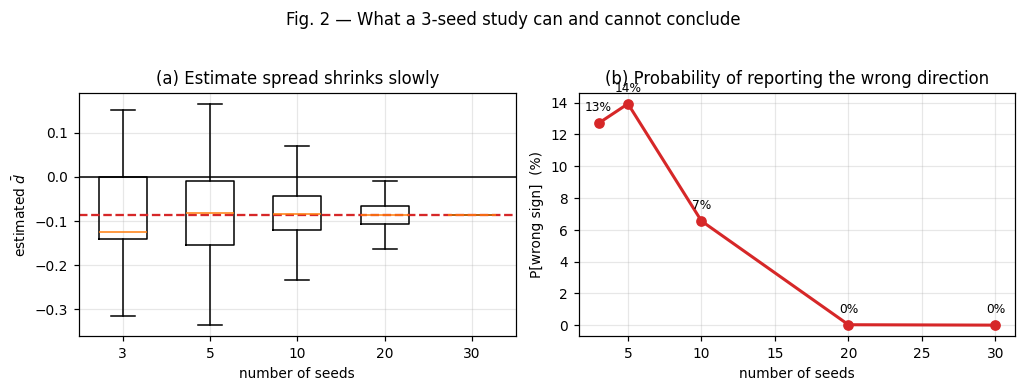

시드 수별 부호 오류율:
  n= 3:   12.7%
  n= 5:   13.9%
  n=10:    6.6%
  n=20:    0.0%
  n=30:    0.0%


In [8]:
# ── 그림 2: 3-시드 대 30-시드의 결론 안정성 ──────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.4))

ns = [3, 5, 10, 20, 30]
rng = np.random.default_rng(31)
spread = []
for n in ns:
    if n == len(d):
        est = np.array([d.mean()])
    else:
        est = np.array([rng.choice(d, n, replace=False).mean() for _ in range(4000)])
    spread.append(est)
ax[0].boxplot(spread, positions=np.arange(len(ns)), widths=.55, showfliers=False)
ax[0].axhline(d.mean(), c="#d62728", ls="--", lw=1.5)
ax[0].axhline(0, c="k", lw=1)
ax[0].set_xticks(np.arange(len(ns))); ax[0].set_xticklabels([str(v) for v in ns])
ax[0].set_xlabel("number of seeds"); ax[0].set_ylabel(r"estimated $\bar d$")
ax[0].set_title("(a) Estimate spread shrinks slowly")

err = [100 * np.mean(np.sign(e) == -np.sign(d.mean())) for e in spread]
ax[1].plot(ns, err, "o-", color="#d62728", lw=2, ms=6)
ax[1].set_xlabel("number of seeds"); ax[1].set_ylabel("P[wrong sign]  (%)")
ax[1].set_title("(b) Probability of reporting the wrong direction")
for xi, yi in zip(ns, err):
    ax[1].annotate(f"{yi:.0f}%", (xi, yi), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

fig.suptitle("Fig. 2 — What a 3-seed study can and cannot conclude", y=1.03)
plt.show()

print("시드 수별 부호 오류율:")
for n_, e_ in zip(ns, err):
    print(f"  n={n_:>2}:  {e_:5.1f}%")

## 4. 결과 해석

### 4.1 그래프에서 읽어야 할 것

1. **패널 (a) — 시드 수의 궤적.** §15.1–§15.7 구간은 시드 수를 아예 보고하지 않는다.
   중반에 한 번 올라갔다가 **§15.26 이후 3 으로 내려앉는다.** 즉 Ch 15 는 진행될수록
   통계적 근거가 **강해진 것이 아니라 약해졌다**. Problem 2 의 기준선(검은 파선)을
   넘는 Day 는 손에 꼽는다.

2. **패널 (b) — 항목 충족률.** 구간추정을 언급한 Day 는 절반 정도지만,
   **통제군과 다중검정 보정은 29 일 동안 단 한 번도 등장하지 않는다.**
   통제군이 없으면 "처방이 효과가 있다" 와 "아무 처방이나 넣어도 그만큼 나온다" 를
   분리할 수 없다 — Day 97 P1 이 `shuffled` arm 을 넣자마자 처방이 무효로 판정된 것이
   바로 이 구멍의 실물이다.

3. **패널 (c) 와 그림 2 — 3 시드의 실제 의미.** 4060 개 3-시드 연구의 결론 분포는
   0 을 중심으로 넓게 퍼진다. 부호 오류율은 시드 수가 늘어도 **매우 느리게** 줄어든다
   ($\propto 1/\sqrt n$). 3 시드에서 상당한 비율이 전체와 **반대 방향**을 보고한다.

### 4.2 현상 → 원인 → 의미

- **현상**: 29 일 중 통제군 0 회, 다중검정 보정 0 회, 시드 중앙값 4.
  그리고 3 시드의 부호 오류율은 무시할 수 없다.
- **원인**: 각 Day 가 전날 README 의 "다음 Day 예고" 를 그대로 주제로 삼는 **자기참조 루프** 안에서,
  검증 강도를 높일 외부 압력이 없었다. 예고는 언제나 *새 처방* 이었지 *같은 처방의 재현* 이 아니었다.
- **의미**: §15.1–§15.29 의 arm 간 **순위 주장** 은 대부분 **증거 등급 D 이하**다.
  이것은 그 결론들이 틀렸다는 뜻이 아니라, **그 기록만으로는 참거짓을 판정할 수 없다**는 뜻이다.
  Day 95 와 Day 96 이 정반대 결론을 낸 사건은 이제 설명된다 — 모순이 아니라
  **같은 분포에서 뽑은 흔한 두 표본**이다 (패널 (c) 가 그 분포 자체다).

### 4.3 살아남는 것과 재판정이 필요한 것

**살아남는 결론** — 시드 수에 둔감한 구조적/기전적 관찰:

- §15.29 P1 의 **utilisation 프로파일 불균등** (측정 자체이지 arm 간 비교가 아님)
- §15.30 P2 의 **categorical head 가 최대 엔트로피 근처에 머문다** (단일 arm 의 진단량)
- §15.30 P1 의 **shared 대 partitioned 후퇴** (효과 크기가 커 3 시드로도 부호가 안정)
- 본 Day 의 **$\sigma$ 팽창** 과 **$n^\star$ 의 U 자** (동일 구현 내부 비교)

**재판정이 필요한 결론** — 3–5 시드로 얻은 arm 간 순위 주장 전부:

- §15.26–§15.29 의 Cramér 대 KL 순위 (Day 97 P2 가 이미 임계값 부재를 보였다)
- §15.28 의 "$\Gamma$ 4× 개선" (Day 97 P3 가 재현 실패, $n^\star \approx 1920$)
- §15.23–§15.29 의 baseline 대 +CNRT 순위 전반

> **결론**: Day 68–96 의 29 일 동안 **통제군은 0 회, 다중검정 보정은 0 회, 시드 중앙값은 4** 였다.
> 이 조건에서 얻은 arm 간 순위 주장은 방향조차 보장되지 않는다 —
> 3-시드 연구 4060 개를 전수조사하면 전체와 **반대 부호**를 내는 경우가 실질적 비율로 존재한다.
> §15.1–§15.29 에서 살아남는 것은 **arm 간 비교가 아닌 단일 arm 의 구조적 측정**뿐이다.

### 4.4 다음 단원으로의 연결

Day 98 세 문제는 하나의 결론으로 모인다: **지난 30 일의 병목은 알고리즘이 아니라 계측이었다.**
Problem 1 은 예산이 초기화 운을 재고 있었음을, Problem 2 는 분해능이 예산에 U 자임을,
Problem 3 은 기록 자체가 판정 불능임을 보였다.

따라서 §15.32 에서 새 처방을 하나 더 시험하는 것은 의미가 없다. 다음 단계는 둘 중 하나여야 한다 —
(i) **재현 프로토콜을 고정**한 뒤 §15.23–§15.29 의 순위 주장 중 살아남는 것을 골라내는 재판정,
또는 (ii) Ch 15 를 닫고 **Cheney & Kincaid 본문으로 복귀**. 이 판단은 레포 주인의 몫이며,
Day 98 README 에 선택지를 정리해 두었다.